# Analysis of the bilayer lipid simulation

In [13]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

## Fluctuations of pressure and temperature

In [14]:
data = np.loadtxt("pressure_and_temperature.xvg", comments=["@", "#"])

time = []
temperature = []
pressure = []

for row in data:
    time.append(row[0])
    temperature.append(row[1])
    pressure.append(row[2])

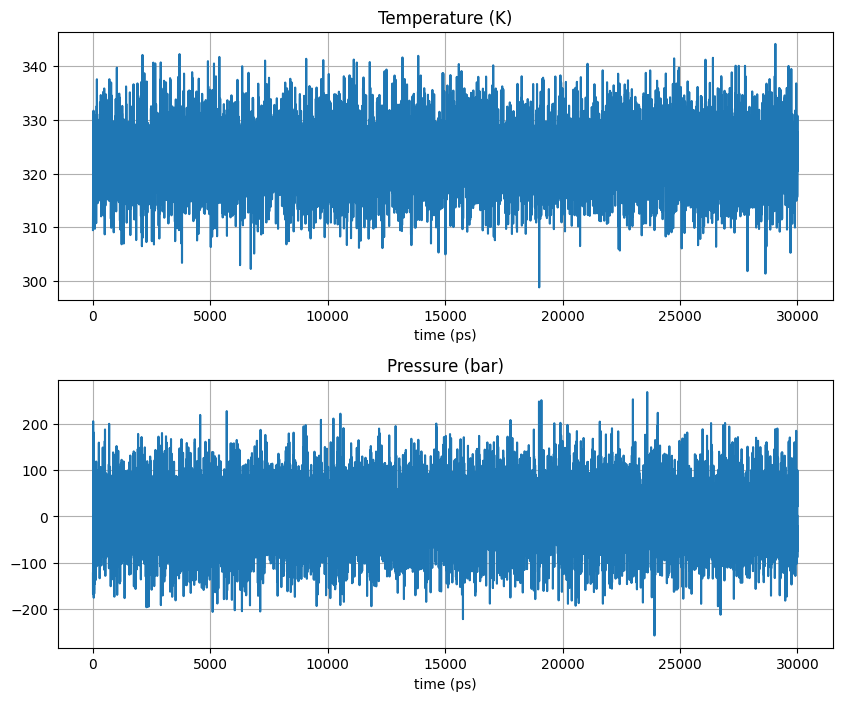

In [15]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize = (10, 8))


ax = axs[0]
ax.plot(time, temperature)
ax.set_title("Temperature (K)")
ax.set_xlabel("time (ps)")
ax.grid()

ax = axs[1]
ax.plot(time, pressure)
ax.set_title("Pressure (bar)")
ax.set_xlabel("time (ps)")
ax.grid()

plt.subplots_adjust(hspace = 0.3)

In [16]:
ntransient = 1000
time_nt = time[ntransient:]
temperature_nt = temperature[ntransient:]
pressure_nt = pressure[ntransient:]


print("Fluctuation std:")
print("Temperature:", np.std(temperature_nt), " K")
print("Pressure: ", np.std(pressure_nt), " bar")

Fluctuation std:
Temperature: 5.850089461184297  K
Pressure:  68.25545231563304  bar


Pressure fluctuations are huge. Controlling pressure in a simulation is very hard, much harder than controlling temperature.

# Area per lipid

Careful because the box dimension does not stay fixed through the simulation. 

Indeed, we are running a simulation at constant temperature (-> energy changes) and pressure (-> volume changes) (**Gibbs ensemble**)!

In [17]:
# Naif calculaation:

box_area = 7.5**2

area_per_lipid =  box_area / 64

area_per_lipid

# Taking into account the right average box area through the simulation:

0.87890625

In [19]:
data = np.loadtxt("box_dimensions.xvg", comments=["@", "#"])


time = []
x = []
y = []
z = []

for step in data:
    time.append(step[0])
    x.append(step[1])
    y.append(step[2])
    z.append(step[3])

In [20]:
print(np.mean(x), np.mean(y), np.mean(z))

7.483101603439656 7.483101603439656 5.61431197440256


In [21]:
true_mean_yz_area = np.mean(y)*np.mean(z)

true_area_per_lipid = true_mean_yz_area / 64
print(true_area_per_lipid)

0.6564447959040978


## Thickness